# 🗑️ Klasifikasi Sampah B3 vs Non-B3
**Transfer Learning dengan MobileNetV2 — Google Colab Edition**

Dataset: Classification Sampah B3 (Roboflow)
- Train : ~14.771 gambar (B3: 3.960 | non-B3: 10.811)
- Valid : ~1.413 gambar (B3: 376 | non-B3: 1.037)
- Test  : ~707 gambar (B3: 195 | non-B3: 512)

> ⚠️ **Pastikan Runtime → Change runtime type → T4 GPU sudah aktif sebelum menjalankan notebook ini!**

## 0. ✅ Cek GPU & Mount Google Drive

In [1]:
# Cek GPU
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {gpus}")
if not gpus:
    print("⚠️  GPU tidak terdeteksi! Pergi ke Runtime → Change runtime type → T4 GPU")
else:
    print("✅ GPU siap digunakan!")

c:\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow : 2.20.0
GPU        : []
⚠️  GPU tidak terdeteksi! Pergi ke Runtime → Change runtime type → T4 GPU


In [2]:
# Local environment setup - tidak perlu mount Google Drive
# Dataset dimulai dari folder lokal
print("✅ Environment setup selesai")

✅ Environment setup selesai


## 1. 📦 Ekstrak Dataset dari ZIP

In [5]:
import zipfile
import os
from pathlib import Path

# ── Path lokal ─────────────────────────────────────────────────────────────
ZIP_PATH    = Path("../dataset/dataset.zip")  # ← ubah ke Path
EXTRACT_DIR = Path("./dataset")              # ← ubah ke Path

# Cek apakah file dataset.zip sudah ada
if not ZIP_PATH.exists():
    print(f"❌ {ZIP_PATH} tidak ditemukan!")
    print("   Download dataset dari Roboflow dan letakkan di folder project/dataset/")
    print("   atau ubah ZIP_PATH di atas sesuai lokasi file Anda")
else:
    # Cek apakah sudah pernah diekstrak
    if not (EXTRACT_DIR / "train").exists():  # ← sekarang berfungsi
        print(f"Mengekstrak {ZIP_PATH} ...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
            zf.extractall(EXTRACT_DIR)
        print(f"✅ Ekstraksi selesai → {EXTRACT_DIR}")
    else:
        print(f"✅ Dataset sudah ada di {EXTRACT_DIR}, skip ekstraksi.")

    # Tampilkan struktur folder hasil ekstraksi
    print("\nStruktur dataset:")
    for split in ["train", "valid", "test"]:
        for cls in ["B3", "non-B3"]:
            folder = EXTRACT_DIR / split / cls
            if folder.exists():
                n = len(list(folder.glob("*.jpg")) + list(folder.glob("*.png")))
                print(f"   {split:5s}/{cls:6s} → {n:5d} gambar")
            else:
                print(f"   ⚠️  {split}/{cls} tidak ditemukan!")

Mengekstrak ..\dataset\dataset.zip ...
✅ Ekstraksi selesai → dataset

Struktur dataset:
   train/B3     → 11124 gambar
   train/non-B3 → 19395 gambar
   valid/B3     →  1011 gambar
   valid/non-B3 →  1721 gambar
   test /B3     →   515 gambar
   test /non-B3 →   867 gambar


## 2. 📚 Import Library

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score, recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

print("✅ Semua library berhasil di-import")

✅ Semua library berhasil di-import


## 3. ⚙️ Konfigurasi Path & Hyperparameter

In [7]:
# ── Path dataset (lokal) ──────────────────────────────────────────────────
DATASET_DIR = Path(EXTRACT_DIR)
TRAIN_DIR   = DATASET_DIR / "train"
VALID_DIR   = DATASET_DIR / "valid"
TEST_DIR    = DATASET_DIR / "test"

# ── Path simpan model (lokal, di folder project) ──────────────────────────
PROJECT_DIR    = Path("./")  # folder project ini
MODEL_PATH     = PROJECT_DIR / "model_b3.h5"
CKPT_PATH      = PROJECT_DIR / "checkpoint_best.h5"

# ── Hyperparameter ────────────────────────────────────────────────────────
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS_FT  = 10    # Fase 1: head training (base frozen)
EPOCHS_UN  = 20    # Fase 2: fine-tuning (partial unfreeze)
SEED       = 42

print(f"Train : {TRAIN_DIR}  | exists: {TRAIN_DIR.exists()}")
print(f"Valid : {VALID_DIR}  | exists: {VALID_DIR.exists()}")
print(f"Test  : {TEST_DIR}   | exists: {TEST_DIR.exists()}")
print(f"Model akan disimpan ke: {MODEL_PATH}")

Train : dataset\train  | exists: True
Valid : dataset\valid  | exists: True
Test  : dataset\test   | exists: True
Model akan disimpan ke: model_b3.h5


## 4. 📂 Load Dataset

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    label_mode="binary",
    interpolation="bilinear",
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="binary",
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="binary",
)

CLASS_NAMES = train_ds.class_names
print(f"Kelas terdeteksi : {CLASS_NAMES}")
print(f"Batch train      : {len(train_ds)}")
print(f"Batch valid      : {len(valid_ds)}")
print(f"Batch test       : {len(test_ds)}")

Found 30519 files belonging to 2 classes.
Found 2732 files belonging to 2 classes.
Found 1382 files belonging to 2 classes.
Kelas terdeteksi : ['B3', 'non-B3']
Batch train      : 954
Batch valid      : 86
Batch test       : 44


## 5. ⚖️ Hitung Class Weight (Penanganan Imbalance)

In [9]:
all_labels = np.concatenate([y.numpy() for _, y in train_ds]).flatten().astype(int)

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight_dict = dict(enumerate(class_weights_arr))

print("Class weight:")
for idx, name in enumerate(CLASS_NAMES):
    print(f"  [{idx}] {name:8s} → weight = {class_weight_dict[idx]:.4f}")

Class weight:
  [0] B3       → weight = 1.3718
  [1] non-B3   → weight = 0.7868


## 6. 🔄 Preprocessing & Augmentasi

In [10]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

def preprocess_train(images, labels):
    images = data_augmentation(images, training=True)
    images = preprocess_input(images)
    return images, labels

def preprocess_eval(images, labels):
    images = preprocess_input(images)
    return images, labels

AUTOTUNE = tf.data.AUTOTUNE

train_ds_proc = train_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
valid_ds_proc = valid_ds.map(preprocess_eval,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds_proc  = test_ds.map(preprocess_eval,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print("✅ Pipeline preprocessing & augmentasi siap")

✅ Pipeline preprocessing & augmentasi siap


## 7. 🖼️ Visualisasi Sampel Dataset

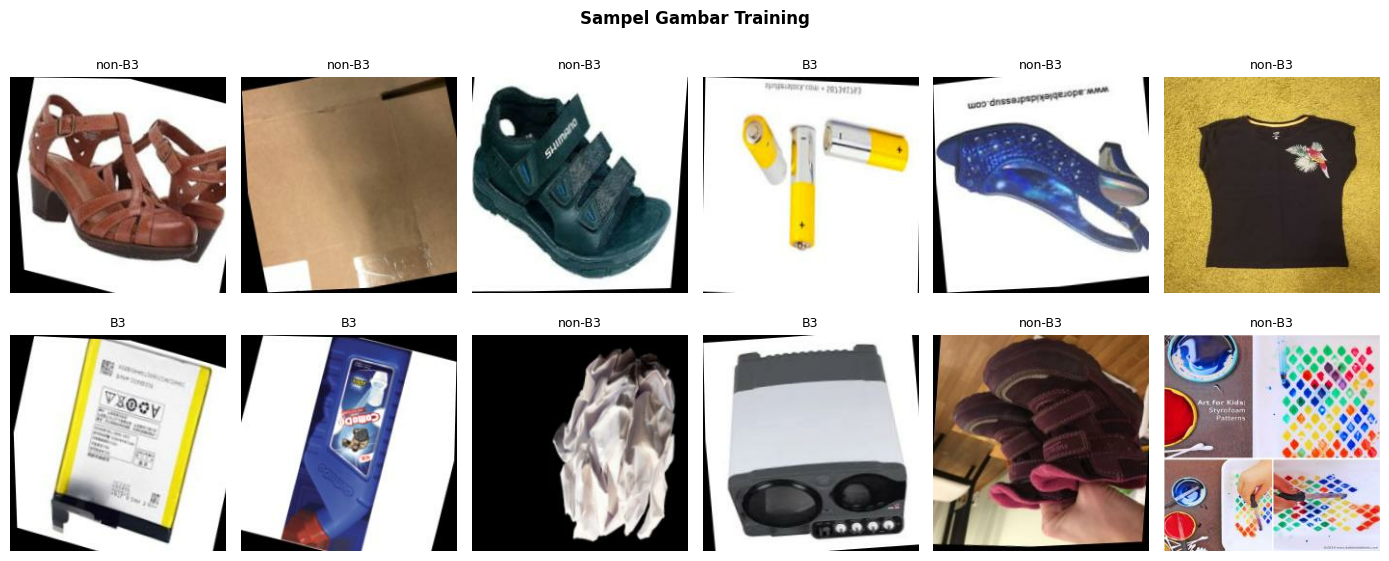

In [11]:
plt.figure(figsize=(14, 6))
for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):
        ax = plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[int(labels[i].numpy().item())], fontsize=9)
        plt.axis("off")
plt.suptitle("Sampel Gambar Training", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. 🏗️ Bangun Model (MobileNetV2 Transfer Learning)

In [12]:
def build_model(trainable_base=False):
    base_model = MobileNetV2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = trainable_base

    inputs = keras.Input(shape=(*IMG_SIZE, 3), name="input_image")
    x = base_model(inputs, training=trainable_base)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu", name="dense_256")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu", name="dense_128")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = keras.Model(inputs, outputs, name="b3_classifier")
    return model, base_model

model, base_model = build_model(trainable_base=False)
model.summary()

Model: "b3_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,065 (10.01 MB)

 Trainable params: 363,521 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 9. 🔥 Fase 1 — Training Head (Base Frozen)

In [13]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ]
)

callbacks_phase1 = [
    EarlyStopping(monitor="val_auc", patience=4, mode="max",
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2,
                     min_lr=1e-6, verbose=1),
    ModelCheckpoint(CKPT_PATH, monitor="val_auc",
                    save_best_only=True, mode="max", verbose=1),
]

print("=" * 60)
print("FASE 1: Training head — base MobileNetV2 di-freeze")
print("=" * 60)

history1 = model.fit(
    train_ds_proc,
    epochs=EPOCHS_FT,
    validation_data=valid_ds_proc,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase1,
    verbose=1,
)

FASE 1: Training head — base MobileNetV2 di-freeze
Epoch 1/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.8505 - auc: 0.9292 - loss: 0.3400 - precision: 0.9056 - recall: 0.8525
Epoch 1: val_auc improved from None to 0.98758, saving model to checkpoint_best.h5



Epoch 1: finished saving model to checkpoint_best.h5
954/954 ━━━━━━━━━━━━━━━━━━━━ 276s 285ms/step - accuracy: 0.8820 - auc: 0.9540 - loss: 0.2778 - precision: 0.9285 - recall: 0.8822 - val_accuracy: 0.9477 - val_auc: 0.9876 - val_loss: 0.1407 - val_precision: 0.9503 - val_recall: 0.9675 - learning_rate: 0.0010
Epoch 2/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.9138 - auc: 0.9731 - loss: 0.2102 - precision: 0.9497 - recall: 0.9121
Epoch 2: val_auc improved from 0.98758 to 0.98968, saving model to checkpoint_best.h5



Epoch 2: finished saving model to checkpoint_best.h5
954/954 ━━━━━━━━━━━━━━━━━━━━ 309s 323ms/step - accuracy: 0.9175 - auc: 0.9753 - loss: 0.2012 - precision: 0.9522 - recall: 0.9163 - val_accuracy: 0.9513 - val_auc: 0.9897 - val_loss: 0.1250 - val_precision: 0.9616 - val_recall: 0.9611 - learning_rate: 0.0010
Epoch 3/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.9258 - auc: 0.9796 - loss: 0.1821 - precision: 0.9586 - recall: 0.9228
Epoch 3: val_auc improved from 0.98968 to 0.99243, saving model to checkpoint_best.h5



Epoch 3: finished saving model to checkpoint_best.h5
954/954 ━━━━━━━━━━━━━━━━━━━━ 290s 303ms/step - accuracy: 0.9283 - auc: 0.9810 - loss: 0.1756 - precision: 0.9600 - recall: 0.9258 - val_accuracy: 0.9616 - val_auc: 0.9924 - val_loss: 0.1068 - val_precision: 0.9736 - val_recall: 0.9651 - learning_rate: 0.0010
Epoch 4/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.9321 - auc: 0.9830 - loss: 0.1659 - precision: 0.9631 - recall: 0.9283
Epoch 4: val_auc improved from 0.99243 to 0.99258, saving model to checkpoint_best.h5



Epoch 4: finished saving model to checkpoint_best.h5
954/954 ━━━━━━━━━━━━━━━━━━━━ 310s 325ms/step - accuracy: 0.9345 - auc: 0.9838 - loss: 0.1616 - precision: 0.9644 - recall: 0.9313 - val_accuracy: 0.9612 - val_auc: 0.9926 - val_loss: 0.1043 - val_precision: 0.9681 - val_recall: 0.9704 - learning_rate: 0.0010
Epoch 5/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.9366 - auc: 0.9848 - loss: 0.1571 - precision: 0.9644 - recall: 0.9343
Epoch 5: val_auc improved from 0.99258 to 0.99309, saving model to checkpoint_best.h5



Epoch 5: finished saving model to checkpoint_best.h5
954/954 ━━━━━━━━━━━━━━━━━━━━ 307s 308ms/step - accuracy: 0.9393 - auc: 0.9855 - loss: 0.1528 - precision: 0.9661 - recall: 0.9374 - val_accuracy: 0.9590 - val_auc: 0.9931 - val_loss: 0.1008 - val_precision: 0.9664 - val_recall: 0.9686 - learning_rate: 0.0010
Epoch 6/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9402 - auc: 0.9871 - loss: 0.1436 - precision: 0.9653 - recall: 0.9394
Epoch 6: val_auc did not improve from 0.99309
954/954 ━━━━━━━━━━━━━━━━━━━━ 307s 321ms/step - accuracy: 0.9421 - auc: 0.9877 - loss: 0.1408 - precision: 0.9674 - recall: 0.9406 - val_accuracy: 0.9627 - val_auc: 0.9928 - val_loss: 0.1016 - val_precision: 0.9687 - val_recall: 0.9721 - learning_rate: 0.0010
Epoch 7/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.9469 - auc: 0.9888 - loss: 0.1340 - precision: 0.9714 - recall: 0.9439
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 7: val_auc did not im


Epoch 8: finished saving model to checkpoint_best.h5
954/954 ━━━━━━━━━━━━━━━━━━━━ 305s 319ms/step - accuracy: 0.9557 - auc: 0.9918 - loss: 0.1129 - precision: 0.9769 - recall: 0.9528 - val_accuracy: 0.9652 - val_auc: 0.9939 - val_loss: 0.0902 - val_precision: 0.9727 - val_recall: 0.9721 - learning_rate: 5.0000e-04
Epoch 9/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.9593 - auc: 0.9926 - loss: 0.1051 - precision: 0.9769 - recall: 0.9585
Epoch 9: val_auc did not improve from 0.99389
954/954 ━━━━━━━━━━━━━━━━━━━━ 300s 314ms/step - accuracy: 0.9598 - auc: 0.9932 - loss: 0.1017 - precision: 0.9782 - recall: 0.9582 - val_accuracy: 0.9656 - val_auc: 0.9922 - val_loss: 0.0921 - val_precision: 0.9700 - val_recall: 0.9756 - learning_rate: 5.0000e-04
Epoch 10/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.9619 - auc: 0.9930 - loss: 0.1032 - precision: 0.9797 - recall: 0.9595
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 10: val_auc

## 10. 🚀 Fase 2 — Fine-Tuning (Partial Unfreeze)

In [14]:
# Unfreeze 50 layer terakhir base model
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Layer base yang di-unfreeze: {trainable_count} dari {len(base_model.layers)}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ]
)

callbacks_phase2 = [
    EarlyStopping(monitor="val_auc", patience=6, mode="max",
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3,
                     min_lr=1e-7, verbose=1),
    ModelCheckpoint(CKPT_PATH, monitor="val_auc",
                    save_best_only=True, mode="max", verbose=1),
]

print("=" * 60)
print("FASE 2: Fine-tuning — 50 layer terakhir di-unfreeze")
print("=" * 60)

history2 = model.fit(
    train_ds_proc,
    epochs=EPOCHS_UN,
    validation_data=valid_ds_proc,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2,
    verbose=1,
)

Layer base yang di-unfreeze: 50 dari 154
FASE 2: Fine-tuning — 50 layer terakhir di-unfreeze
Epoch 1/20
954/954 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.9324 - auc: 0.9807 - loss: 0.1802 - precision: 0.9607 - recall: 0.9313
Epoch 1: val_auc improved from None to 0.99101, saving model to checkpoint_best.h5



Epoch 1: finished saving model to checkpoint_best.h5
954/954 ━━━━━━━━━━━━━━━━━━━━ 455s 469ms/step - accuracy: 0.9421 - auc: 0.9857 - loss: 0.1520 - precision: 0.9684 - recall: 0.9396 - val_accuracy: 0.9418 - val_auc: 0.9910 - val_loss: 0.1503 - val_precision: 0.9875 - val_recall: 0.9192 - learning_rate: 1.0000e-04
Epoch 2/20
954/954 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.9610 - auc: 0.9926 - loss: 0.1052 - precision: 0.9794 - recall: 0.9585
Epoch 2: val_auc improved from 0.99101 to 0.99247, saving model to checkpoint_best.h5



Epoch 2: finished saving model to checkpoint_best.h5
954/954 ━━━━━━━━━━━━━━━━━━━━ 443s 463ms/step - accuracy: 0.9625 - auc: 0.9933 - loss: 0.1002 - precision: 0.9803 - recall: 0.9604 - val_accuracy: 0.9649 - val_auc: 0.9925 - val_loss: 0.1059 - val_precision: 0.9845 - val_recall: 0.9593 - learning_rate: 1.0000e-04
Epoch 3/20
954/954 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9661 - auc: 0.9946 - loss: 0.0895 - precision: 0.9823 - recall: 0.9638
Epoch 3: val_auc improved from 0.99247 to 0.99283, saving model to checkpoint_best.h5



Epoch 3: finished saving model to checkpoint_best.h5
954/954 ━━━━━━━━━━━━━━━━━━━━ 421s 440ms/step - accuracy: 0.9690 - auc: 0.9956 - loss: 0.0798 - precision: 0.9844 - recall: 0.9666 - val_accuracy: 0.9638 - val_auc: 0.9928 - val_loss: 0.0954 - val_precision: 0.9805 - val_recall: 0.9617 - learning_rate: 1.0000e-04
Epoch 4/20
954/954 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.9748 - auc: 0.9967 - loss: 0.0676 - precision: 0.9876 - recall: 0.9724
Epoch 4: val_auc did not improve from 0.99283
954/954 ━━━━━━━━━━━━━━━━━━━━ 421s 440ms/step - accuracy: 0.9752 - auc: 0.9967 - loss: 0.0676 - precision: 0.9880 - recall: 0.9728 - val_accuracy: 0.9528 - val_auc: 0.9890 - val_loss: 0.1618 - val_precision: 0.9914 - val_recall: 0.9332 - learning_rate: 1.0000e-04
Epoch 5/20
954/954 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.9768 - auc: 0.9969 - loss: 0.0637 - precision: 0.9887 - recall: 0.9745
Epoch 5: val_auc did not improve from 0.99283
954/954 ━━━━━━━━━━━━━━━━━━━━ 401s 419ms/step - acc


Epoch 6: finished saving model to checkpoint_best.h5
954/954 ━━━━━━━━━━━━━━━━━━━━ 395s 413ms/step - accuracy: 0.9806 - auc: 0.9975 - loss: 0.0541 - precision: 0.9903 - recall: 0.9791 - val_accuracy: 0.9671 - val_auc: 0.9945 - val_loss: 0.0980 - val_precision: 0.9880 - val_recall: 0.9593 - learning_rate: 1.0000e-04
Epoch 7/20
954/954 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.9850 - auc: 0.9990 - loss: 0.0370 - precision: 0.9932 - recall: 0.9830
Epoch 7: val_auc improved from 0.99447 to 0.99682, saving model to checkpoint_best.h5



Epoch 7: finished saving model to checkpoint_best.h5
954/954 ━━━━━━━━━━━━━━━━━━━━ 393s 411ms/step - accuracy: 0.9874 - auc: 0.9991 - loss: 0.0335 - precision: 0.9940 - recall: 0.9860 - val_accuracy: 0.9773 - val_auc: 0.9968 - val_loss: 0.0650 - val_precision: 0.9837 - val_recall: 0.9802 - learning_rate: 3.0000e-05
Epoch 8/20
954/954 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9899 - auc: 0.9992 - loss: 0.0292 - precision: 0.9945 - recall: 0.9894
Epoch 8: val_auc did not improve from 0.99682
954/954 ━━━━━━━━━━━━━━━━━━━━ 394s 412ms/step - accuracy: 0.9908 - auc: 0.9992 - loss: 0.0280 - precision: 0.9954 - recall: 0.9900 - val_accuracy: 0.9813 - val_auc: 0.9950 - val_loss: 0.0615 - val_precision: 0.9804 - val_recall: 0.9901 - learning_rate: 3.0000e-05
Epoch 9/20
954/954 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9910 - auc: 0.9992 - loss: 0.0263 - precision: 0.9957 - recall: 0.9901
Epoch 9: val_auc did not improve from 0.99682
954/954 ━━━━━━━━━━━━━━━━━━━━ 393s 412ms/step - acc

## 11. 📈 Kurva Training

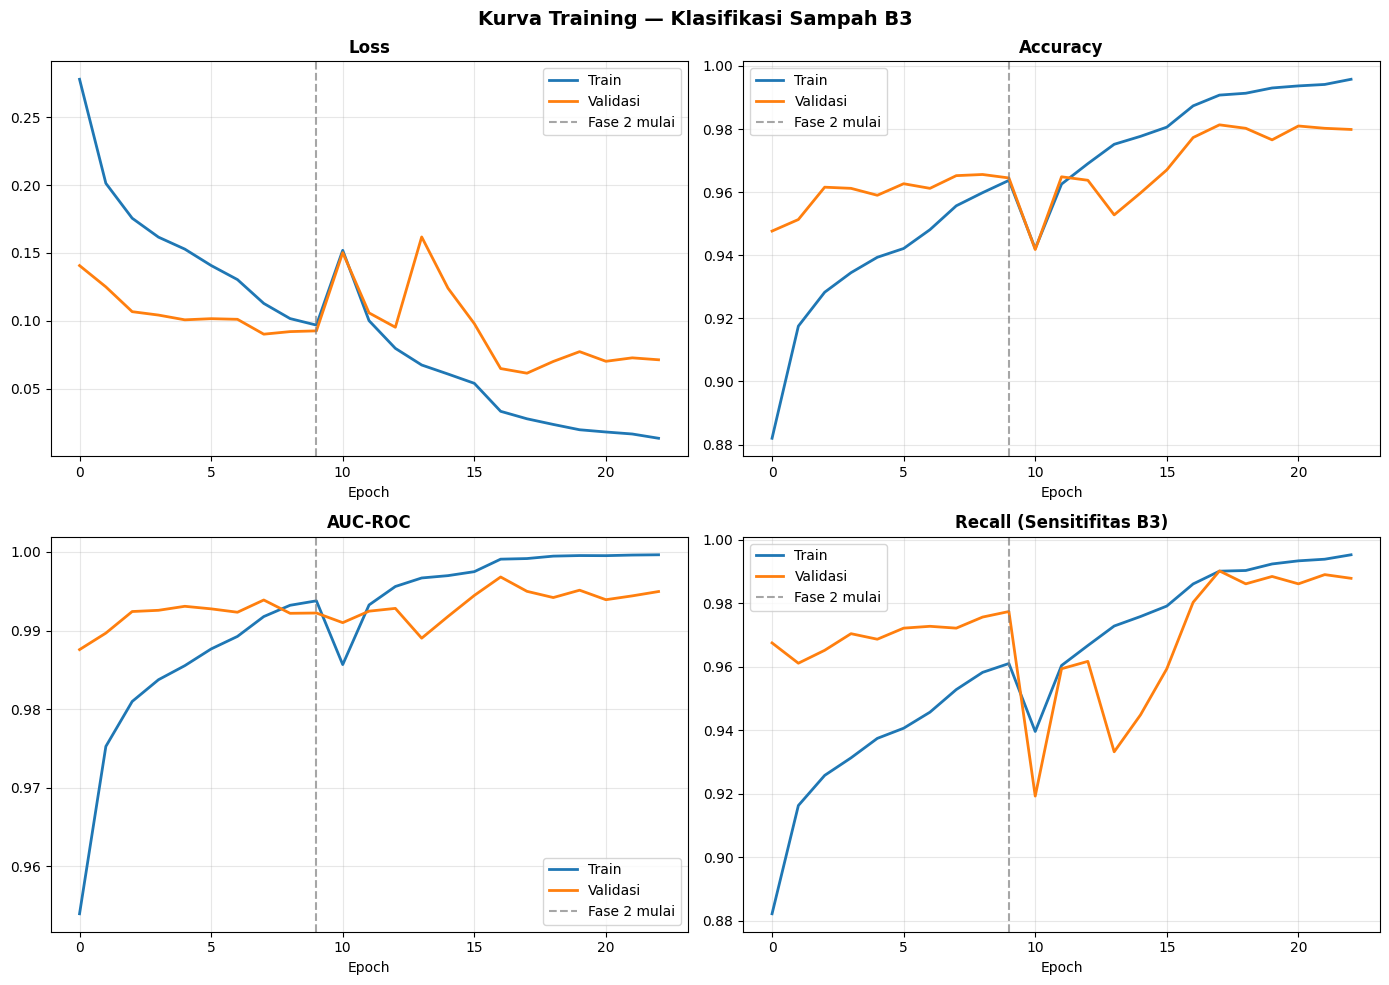

✅ Plot disimpan ke folder project


In [15]:
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

hist = merge_histories(history1, history2)
n_phase1 = len(history1.history["loss"])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Kurva Training — Klasifikasi Sampah B3", fontsize=14, fontweight="bold")

for ax, (train_key, val_key, title) in zip(axes.flat, [
    ("loss",     "val_loss",     "Loss"),
    ("accuracy", "val_accuracy", "Accuracy"),
    ("auc",      "val_auc",      "AUC-ROC"),
    ("recall",   "val_recall",   "Recall (Sensitifitas B3)"),
]):
    ax.plot(hist[train_key], label="Train", linewidth=2)
    ax.plot(hist[val_key],   label="Validasi", linewidth=2)
    ax.axvline(n_phase1 - 1, color="gray", linestyle="--", alpha=0.7, label="Fase 2 mulai")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot disimpan ke folder project")

## 12. 📊 Evaluasi pada Data Test

In [16]:
print("=" * 60)
print("EVALUASI MODEL PADA DATA TEST")
print("=" * 60)

test_results = model.evaluate(test_ds_proc, verbose=1)
test_metrics = dict(zip(model.metrics_names, test_results))

print("\n📊 Hasil Evaluasi Test Set:")
for name, value in test_metrics.items():
    print(f"   {name:12s} : {value:.4f}")

EVALUASI MODEL PADA DATA TEST
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 240ms/step - accuracy: 0.9703 - auc: 0.9908 - loss: 0.1008 - precision: 0.9736 - recall: 0.9792

📊 Hasil Evaluasi Test Set:
   loss         : 0.1008
   compile_metrics : 0.9703


## 13. 🔢 Confusion Matrix

44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 242ms/step


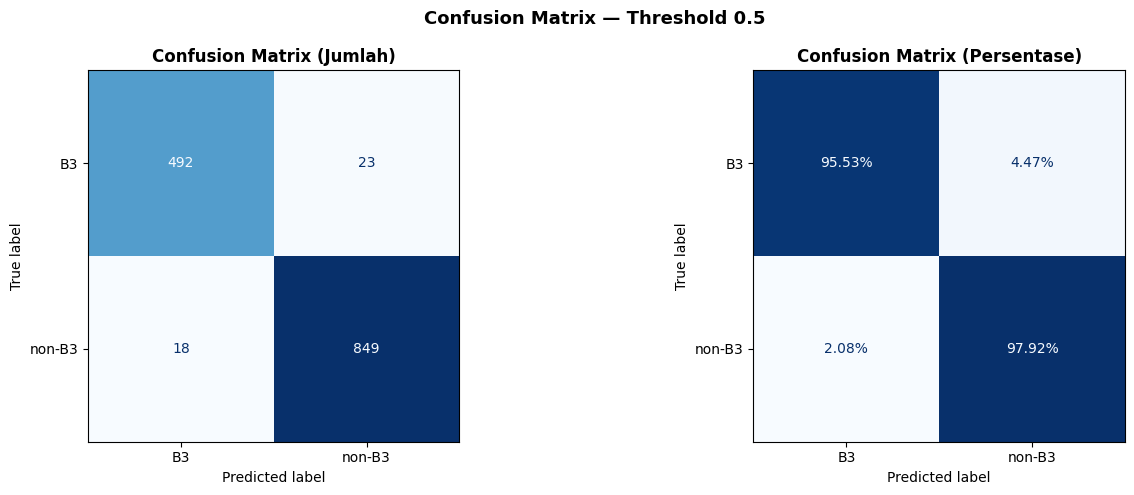

✅ Plot disimpan ke folder project


In [17]:
y_pred_proba = model.predict(test_ds_proc, verbose=1).flatten()
y_true       = np.concatenate([y.numpy() for _, y in test_ds]).flatten().astype(int)

THRESHOLD = 0.5
y_pred = (y_pred_proba >= THRESHOLD).astype(int)

cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (Jumlah)", fontweight="bold")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_NAMES).plot(
    ax=axes[1], colorbar=False, cmap="Blues", values_format=".2%")
axes[1].set_title("Confusion Matrix (Persentase)", fontweight="bold")

plt.suptitle(f"Confusion Matrix — Threshold {THRESHOLD}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot disimpan ke folder project")

## 14. 📋 Classification Report

In [18]:
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

b3_idx    = CLASS_NAMES.index("B3")
prec_b3   = precision_score(y_true, y_pred, pos_label=b3_idx)
recall_b3 = recall_score(y_true, y_pred, pos_label=b3_idx)
f1_b3     = f1_score(y_true, y_pred, pos_label=b3_idx)

print("\n🔴 Fokus kelas B3 (kritis):")
print(f"   Precision : {prec_b3:.4f}")
print(f"   Recall    : {recall_b3:.4f}  ← sensitifitas deteksi B3")
print(f"   F1-Score  : {f1_b3:.4f}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

          B3     0.9647    0.9553    0.9600       515
      non-B3     0.9736    0.9792    0.9764       867

    accuracy                         0.9703      1382
   macro avg     0.9692    0.9673    0.9682      1382
weighted avg     0.9703    0.9703    0.9703      1382


🔴 Fokus kelas B3 (kritis):
   Precision : 0.9647
   Recall    : 0.9553  ← sensitifitas deteksi B3
   F1-Score  : 0.9600


## 15. 🎯 Threshold Optimal (F1 B3)

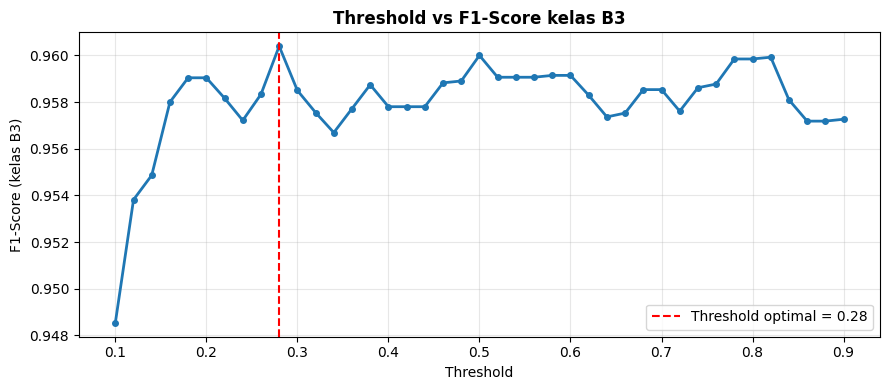


✅ Threshold optimal : 0.28 (F1 B3 = 0.9604)
   Gunakan nilai ini di aplikasi Streamlit!


In [19]:
thresholds    = np.arange(0.1, 0.91, 0.02)
f1_b3_scores  = [f1_score(y_true, (y_pred_proba >= t).astype(int),
                           pos_label=0, zero_division=0) for t in thresholds]

best_t  = thresholds[np.argmax(f1_b3_scores)]
best_f1 = max(f1_b3_scores)

plt.figure(figsize=(9, 4))
plt.plot(thresholds, f1_b3_scores, marker="o", markersize=4, linewidth=2)
plt.axvline(best_t, color="red", linestyle="--", label=f"Threshold optimal = {best_t:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1-Score (kelas B3)")
plt.title("Threshold vs F1-Score kelas B3", fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "threshold_f1.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ Threshold optimal : {best_t:.2f} (F1 B3 = {best_f1:.4f})")
print(f"   Gunakan nilai ini di aplikasi Streamlit!")

## 16. 💾 Simpan Model ke Google Drive

In [20]:
# Simpan H5 (legacy, untuk kompatibilitas)
model.save(str(MODEL_PATH))
print(f"✅ Model H5 disimpan → {MODEL_PATH}")

# Simpan format .keras (native Keras 3.x, lebih robust)
keras_path = PROJECT_DIR / "model_b3.keras"
model.save(str(keras_path))
print(f"✅ Model .keras disimpan → {keras_path}")

# Simpan SavedModel (untuk TFLite/TFServing) — pakai export() di Keras 3.x
saved_model_path = PROJECT_DIR / "model_b3_savedmodel"
model.export(str(saved_model_path))
print(f"✅ SavedModel disimpan → {saved_model_path}/")

h5_size = os.path.getsize(str(MODEL_PATH)) / 1e6
print(f"\nUkuran model H5 : {h5_size:.2f} MB")

print("\n📁 Semua file tersimpan di folder project:")
print(f"   {PROJECT_DIR}/")
for fname in ["model_b3.h5", "model_b3.keras", "checkpoint_best.h5"]:
    path = PROJECT_DIR / fname
    exists = "✅" if path.exists() else "❌"
    print(f"   {exists} {fname}")

✅ Model H5 disimpan → model_b3.h5
✅ Model .keras disimpan → model_b3.keras
INFO:tensorflow:Assets written to: model_b3_savedmodel\assets


INFO:tensorflow:Assets written to: model_b3_savedmodel\assets


Saved artifact at 'model_b3_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1616005971216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1616010691600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1616010691024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1616005971600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1616005970832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1616010691792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1616010693520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1616010693328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1616010692944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1616010694096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1616010692560: TensorSpec(shape=

## 17. ✅ Ringkasan Hasil

In [21]:
print("=" * 60)
print("  RINGKASAN HASIL TRAINING & EVALUASI")
print("=" * 60)
print(f"  Model         : MobileNetV2 (Transfer Learning)")
print(f"  Input size    : {IMG_SIZE[0]}×{IMG_SIZE[1]} px")
print(f"  Epochs fase 1 : {len(history1.history['loss'])}")
print(f"  Epochs fase 2 : {len(history2.history['loss'])}")
print()
print("  📊 Metrik TEST SET:")
for name, value in test_metrics.items():
    print(f"     {name:12s}: {value:.4f}")
print()
print(f"  🔴 Kelas B3:")
print(f"     Precision : {prec_b3:.4f}")
print(f"     Recall    : {recall_b3:.4f}")
print(f"     F1-Score  : {f1_b3:.4f}")
print()
print(f"  🌐 Threshold untuk Streamlit: {best_t:.2f}")
print(f"  💾 Model tersimpan di Drive  : model_b3.h5")
print("=" * 60)

  RINGKASAN HASIL TRAINING & EVALUASI
  Model         : MobileNetV2 (Transfer Learning)
  Input size    : 224×224 px
  Epochs fase 1 : 10
  Epochs fase 2 : 13

  📊 Metrik TEST SET:
     loss        : 0.1008
     compile_metrics: 0.9703

  🔴 Kelas B3:
     Precision : 0.9647
     Recall    : 0.9553
     F1-Score  : 0.9600

  🌐 Threshold untuk Streamlit: 0.28
  💾 Model tersimpan di Drive  : model_b3.h5
